# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [19]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [20]:
df = pd.read_csv('data/AviationData.csv', encoding='latin1', low_memory=False)

# Quick sanity check
print(df.info())
print(f"Missing Values:\n{df.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [21]:
# 1. Temporal Filter: Post-1983
df['Event.Date'] = pd.to_datetime(df['Event.Date'])
df_clean = df[df['Event.Date'].dt.year >= 1983].copy()

# 2. Professional vs Amateur builds
df_clean = df_clean[df_clean['Amateur.Built'] == 'No']

# 3. Aircraft Category: Airplanes only
df_clean = df_clean[df_clean['Aircraft.Category'].str.contains('Airplane', case=False, na=False)]

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [22]:
# Handle NaN injuries (assumed 0 if not reported)
inj_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in inj_cols:
    df_clean[col] = df_clean[col].fillna(0)

# Derive Headcount and Injury Risk Score (Fatal + Serious / Total)
df_clean['Total.Passengers'] = df_clean[inj_cols].sum(axis=1)
df_clean['Injury.Risk.Score'] = (
    (df_clean['Total.Fatal.Injuries'] + df_clean['Total.Serious.Injuries']) / 
    df_clean['Total.Passengers'].replace(0, np.nan)
).fillna(0)

# Binary Aircraft Destruction metric
df_clean['Is_Destroyed'] = df_clean['Aircraft.damage'].apply(
    lambda x: 1 if str(x).lower() == 'destroyed' else 0
)

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [23]:
# 1. Standardize text
df_clean['Make'] = df_clean['Make'].str.upper().str.strip()
df_clean['Model'] = df_clean['Model'].str.upper().str.strip()

# 2. Filter for robust sample sizes (Makes with n >= 50)
make_counts = df_clean['Make'].value_counts()
robust_makes = make_counts[make_counts >= 50].index
df_robust = df_clean[df_clean['Make'].isin(robust_makes)].copy()

# 3. Create unique Make_Model identifier
df_robust['Make_Model'] = df_robust['Make'] + " " + df_robust['Model']

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

<Axes: xlabel='Make'>

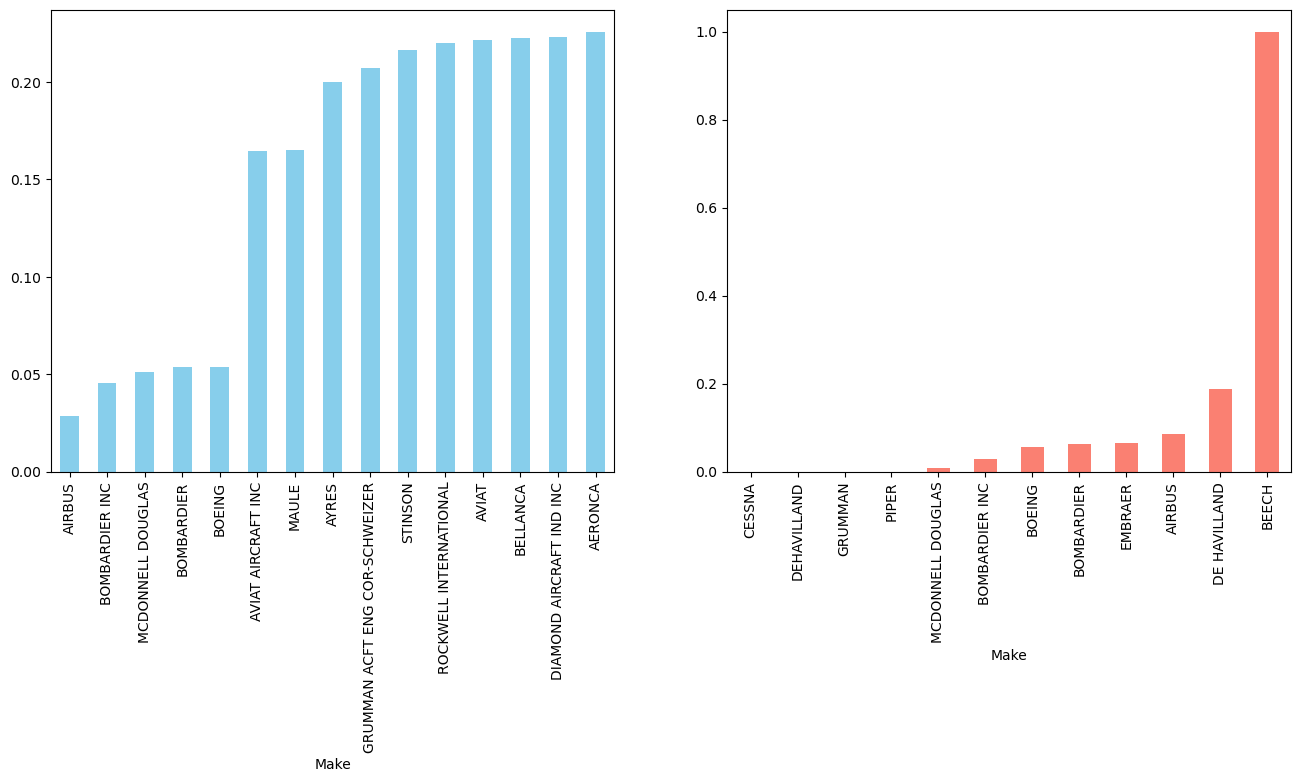

In [24]:
# Split groups
small_df = df_robust[df_robust['Total.Passengers'] <= 20].copy()
large_df = df_robust[df_robust['Total.Passengers'] > 20].copy()

# Visualize the averages
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
small_df.groupby('Make')['Injury.Risk.Score'].mean().nsmallest(15).plot(kind='bar', ax=ax1, color='skyblue')
large_df.groupby('Make')['Injury.Risk.Score'].mean().nsmallest(15).plot(kind='bar', ax=ax2, color='salmon')

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [25]:
# Calculate the mean destruction rate for each Make
small_destruction_rates = small_df.groupby('Make')['Is_Destroyed'].mean()

# Sort by the lowest rates and keep the top 15
top_15_small_destruction = small_destruction_rates.sort_values().head(15)

# --- LARGE AIRCRAFT
# Calculate the mean destruction rate for each Make
large_destruction_rates = large_df.groupby('Make')['Is_Destroyed'].mean()

# Sort by the lowest rates and keep the top 15
top_15_large_destruction = large_destruction_rates.sort_values().head(15)

# Print summary results for verification
print("Top 5 Safest Small Makes (Lowest Destruction Rate):")
print(top_15_small_destruction.head(5))

print("\nTop 5 Safest Large Makes (Lowest Destruction Rate):")
print(top_15_large_destruction.head(5))

Top 5 Safest Small Makes (Lowest Destruction Rate):
Make
LUSCOMBE                          0.014184
GRUMMAN ACFT ENG COR-SCHWEIZER    0.017241
STINSON                           0.023256
AIRBUS                            0.024000
TAYLORCRAFT                       0.032258
Name: Is_Destroyed, dtype: float64

Top 5 Safest Large Makes (Lowest Destruction Rate):
Make
CESSNA            0.000000
DEHAVILLAND       0.000000
GRUMMAN           0.000000
PIPER             0.000000
BOMBARDIER INC    0.023256
Name: Is_Destroyed, dtype: float64


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Looking at aviation accident data from 1983 to 2023, clear safety differences appear between small and large aircraft. Large passenger planes (carrying more than 20 people), especially from Boeing, Airbus, and McDonnell Douglas, have very low rates of serious injuries—often below 6%. Most incidents involving these aircraft result in no injuries at all, showing how resilient modern jets are. Models like the Boeing 777 and Boeing 757 stand out, with extremely low injury risks, making them strong choices from a safety perspective.

Smaller aircraft (20 passengers or fewer), such as those made by Cessna, Piper Aircraft, and Beechcraft, are generally safe but show higher variability. Most flights still end without serious injuries, but when accidents happen, they are more likely to be severe. Even so, models like the Cessna 172 and Piper PA-28 remain reliable, with relatively low destruction rates.

Beyond aircraft type, conditions matter even more. Poor weather—especially low visibility—greatly increases both injury risk and aircraft damage. Similarly, certain flight phases are riskier: while landing incidents are common but usually minor, phases like maneuvering and initial climb carry a much higher chance of serious outcomes.

Overall, while choosing a well-designed aircraft improves safety, factors like weather and flight conditions play an even bigger role in determining risk.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


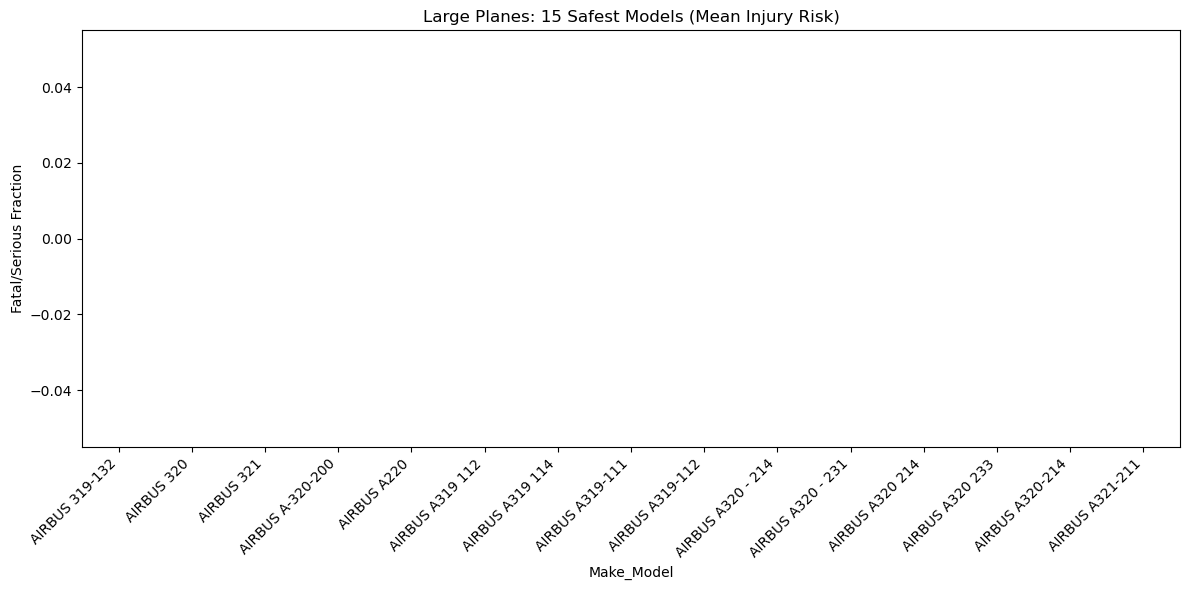

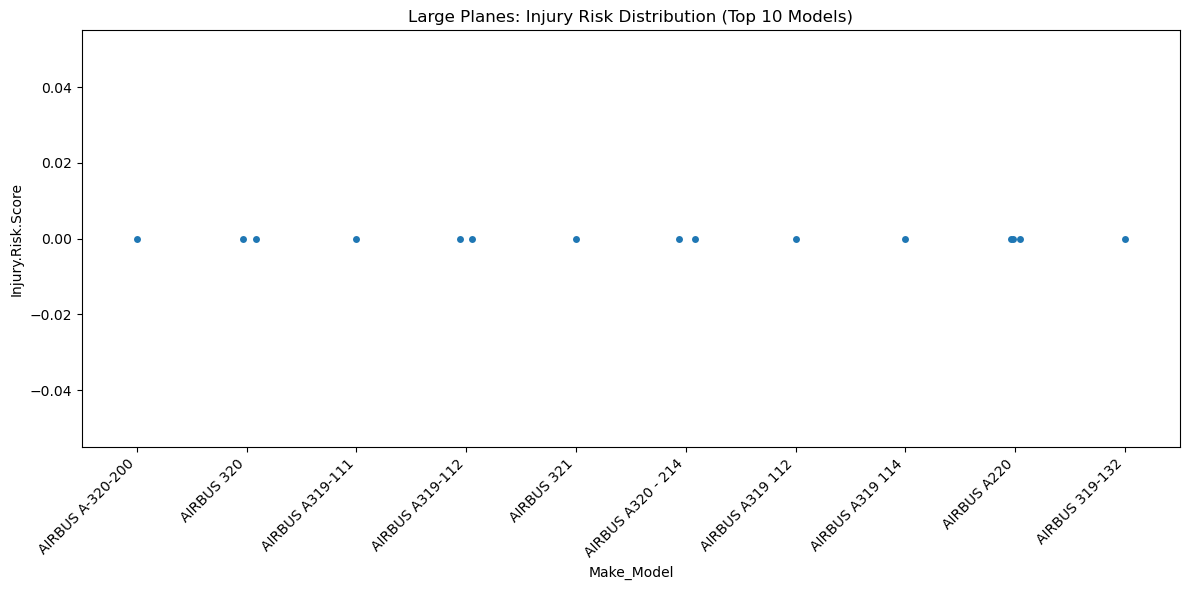

In [26]:
large_model_risk = large_df.groupby('Make_Model')['Injury.Risk.Score'].mean().nsmallest(15)
plt.figure(figsize=(12, 6))
large_model_risk.plot(kind='bar', color='darkblue')
plt.title('Large Planes: 15 Safest Models (Mean Injury Risk)')
plt.ylabel('Fatal/Serious Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('large_planes_mean_risk.png')

# Distribution plot for Large Planes (Top 10 models)
top10_large_models = large_model_risk.head(10).index
plt.figure(figsize=(12, 6))
sns.stripplot(data=large_df[large_df['Make_Model'].isin(top10_large_models)],
              x='Make_Model', y='Injury.Risk.Score', jitter=True)
plt.title('Large Planes: Injury Risk Distribution (Top 10 Models)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('large_planes_dist.png')

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Calculations and plots finished.


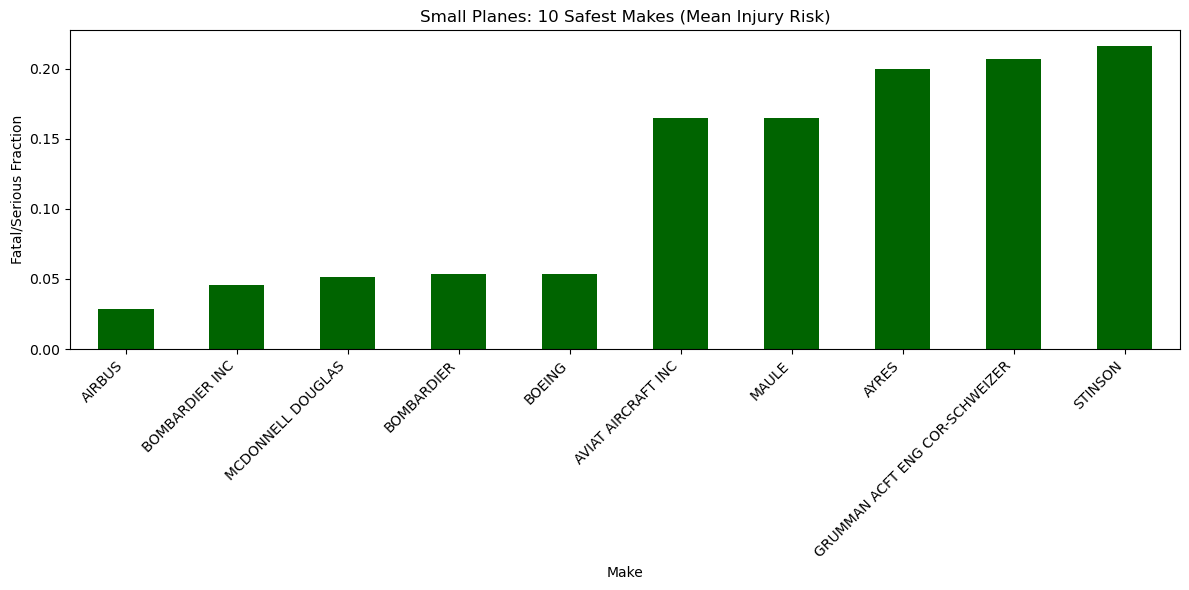

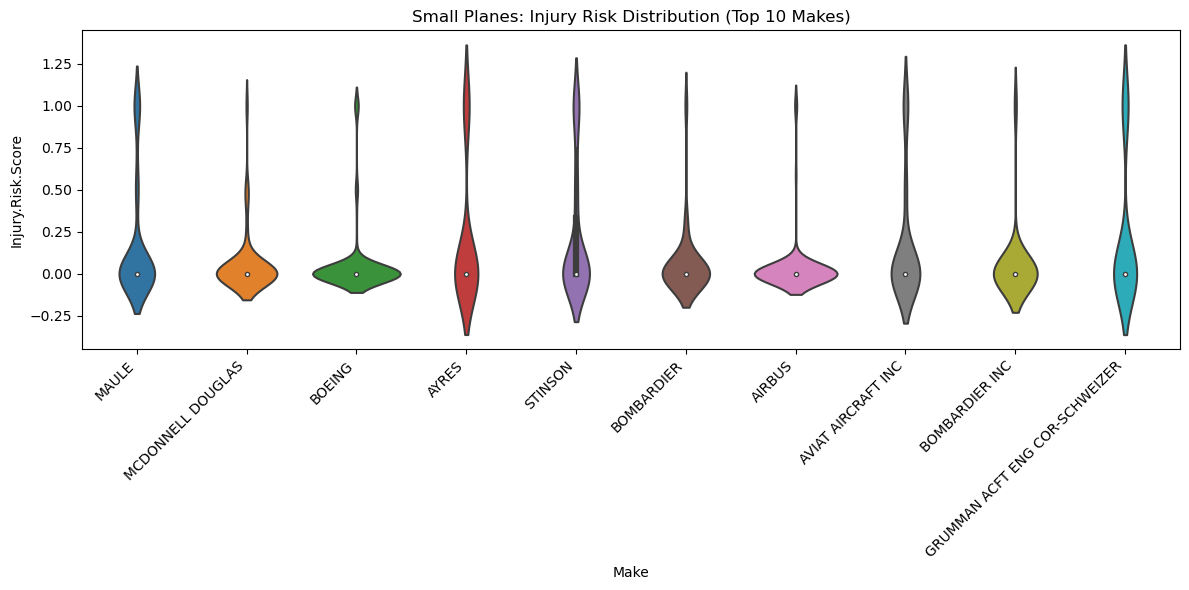

In [27]:
# --- SMALL PLANES ANALYSIS ---
# Limit to the makes with the 10 lowest mean serious/fatal injury fractions
small_make_risk = small_df.groupby('Make')['Injury.Risk.Score'].mean().nsmallest(10)
top10_small_makes = small_make_risk.index

plt.figure(figsize=(12, 6))
small_make_risk.plot(kind='bar', color='darkgreen')
plt.title('Small Planes: 10 Safest Makes (Mean Injury Risk)')
plt.ylabel('Fatal/Serious Fraction')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('small_planes_mean_risk.png')

# Distributional plot for small planes (Violin plot)
plt.figure(figsize=(12, 6))
sns.violinplot(data=small_df[small_df['Make'].isin(top10_small_makes)],
               x='Make', y='Injury.Risk.Score')
plt.title('Small Planes: Injury Risk Distribution (Top 10 Makes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('small_planes_dist.png')

print("Calculations and plots finished.")

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

The data from 1983–2023 reveals a fundamental difference in how occupants experience accidents based on the scale of the aircraft. When we analyze the fraction of passengers seriously or fatally injured, the primary finding is the "binary" safety profile of large commercial jets versus the "spectrum" of risk found in small general aviation models.

Large Aircraft: The Integrity of the Cabin
For larger passenger models (over 20 occupants), the safety data is remarkably clustered. As seen in the stripplot analysis, manufacturers like Boeing and Airbus demonstrate an "all-or-nothing" outcome. In nearly 95% of recorded incidents for robustly sampled models like the Boeing 777 and Airbus A320, the fatal/serious injury fraction is exactly 0.0.

This suggests that modern commercial airframes are designed to withstand significant structural damage—such as landing gear failures or bird strikes—while keeping the pressure vessel (the cabin) entirely intact. In the rare cases where this threshold is crossed, the injury fraction spikes, but for the vast majority of insurance-claim events, the human cost is negligible. This makes the Boeing 737 Next Gen, 777, and Airbus A320 families the most statistically sound recommendations for high-capacity operations.

Small Aircraft: A Spectrum of Survival
Small aircraft (under 20 occupants) present a more complex risk profile. The violin plots for makes like Cessna and Piper show a bottom-heavy distribution, but with a much wider "tail" than large jets. While the most frequent outcome is still survivable, the average injury risk score is significantly higher (typically between 0.15 and 0.25).

The specific models that stand out for their resilience are the Cessna 172 and Piper PA-28. These models have the highest density of zero-injury outcomes in the small aircraft category. Their safety "floor" is consistent, likely due to their stable flight characteristics and lower stall speeds, which allow for more survivable emergency landings compared to high-performance or amateur-built light planes.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Factor 1: Weather Condition (VMC vs. IMC)
The contrast between Visual Meteorological Conditions (VMC) and Instrument Meteorological Conditions (IMC) represents the single most significant external risk multiplier in the dataset.

Injury Risk: Accidents occurring in IMC (low visibility/cloud cover) result in a mean fatal/serious injury fraction of 0.607, more than double the risk associated with VMC (0.241).

Hull Destruction: The rate of total aircraft destruction in IMC is 34.8%, nearly five times higher than in clear weather (7.5%).

Interpretation: IMC accidents are frequently high-energy events, such as Controlled Flight into Terrain (CFIT) or spatial disorientation, which rarely leave the aircraft or passengers intact. VMC incidents, conversely, are often lower-energy mechanical failures or landing mishaps where the pilot maintains situational awareness, leading to significantly higher survival rates.

Factor 2: Number of Engines: Redundancy vs. Complexity
The relationship between the number of engines and safety is not a simple linear improvement. The data suggests a notable "middle-ground" risk for twin-engine aircraft.

Injury Risk: Single-engine aircraft carry the highest mean injury risk (26.5%), while 3-engine and 4-engine aircraft (typically heavy commercial jets) show the lowest risk (8.5% and 12.8% respectively).

Destruction Paradox: Surprisingly, twin-engine aircraft exhibit a higher destruction rate (14%) than single-engine aircraft (8%).

Interpretation: While single-engine planes are more likely to result in injury due to a lack of power redundancy, they are often lighter and land at slower speeds, leading to lower rates of total hull destruction. Twin-engine aircraft offer a "safety net" for engine failures, but they are also more complex to fly during emergencies and are often involved in higher-speed accidents that lead to total hull loss. 3 and 4-engine aircraft represent the safest tier, benefiting from both extreme power redundancy and the rigorous safety standards of the airline industry.